![image info](https://raw.githubusercontent.com/albahnsen/MIAD_ML_and_NLP/main/images/banner_1.png)

# Taller: Construcción e implementación de árboles de decisión y métodos de ensamblaje

En este taller podrá poner en práctica los sus conocimientos sobre construcción e implementación de árboles de decisión y métodos de ensamblajes. El taller está constituido por 9 puntos, 5 relacionados con árboles de decisión (parte A) y 4 con métodos de ensamblaje (parte B).

## Parte A - Árboles de decisión

En esta parte del taller se usará el conjunto de datos de Capital Bikeshare de Kaggle, donde cada observación representa el alquiler de bicicletas durante una hora y día determinado. Para más detalles puede visitar los siguientes enlaces: [datos](https://archive.ics.uci.edu/ml/machine-learning-databases/00275/Bike-Sharing-Dataset.zip), [dicccionario de datos](https://archive.ics.uci.edu/ml/datasets/Bike+Sharing+Dataset#).

### Datos prestamo de bicicletas

In [44]:
import warnings
warnings.filterwarnings('ignore')

In [45]:
# Importación de librerías
%matplotlib inline
import pandas as pd
import numpy as np
from sklearn.model_selection import cross_val_score
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor, export_graphviz

In [46]:
# Lectura de la información de archivo .csv
bikes = pd.read_csv('https://raw.githubusercontent.com/davidzarruk/MIAD_ML_NLP_2023/main/datasets/bikeshare.csv', index_col='datetime', parse_dates=True)

# Renombrar variable "count" a "total"
bikes.rename(columns={'count':'total'}, inplace=True)

# Crear la hora como una variable 
bikes['hour'] = bikes.index.hour

# Visualización de los datos
bikes.head()

,season,holiday,workingday,weather,temp,atemp,humidity,windspeed,casual,registered,total,hour
datetime,,,,,,,,,,,,
2011-01-01 00:00:00,1,0,0,1,9.84,14.395,81,0.0,3,13,16,0
2011-01-01 01:00:00,1,0,0,1,9.02,13.635,80,0.0,8,32,40,1
2011-01-01 02:00:00,1,0,0,1,9.02,13.635,80,0.0,5,27,32,2
2011-01-01 03:00:00,1,0,0,1,9.84,14.395,75,0.0,3,10,13,3
2011-01-01 04:00:00,1,0,0,1,9.84,14.395,75,0.0,0,1,1,4


### Punto 1 - Análisis descriptivo

Ejecute las celdas 1.1 y 1.2. A partir de los resultados realice un análisis descriptivo sobre las variables "season" y "hour", escriba sus inferencias sobre los datos. Para complementar su análisis puede usar métricas como máximo, mínimo, percentiles entre otros.

In [47]:
# Celda 1.1
print(f"Media: {bikes.groupby('season').total.mean()}")
print(f"Desviacion estandar: {bikes.groupby('season').total.std()}")
print(f"Valor minimo: {bikes.groupby('season').total.min()}")
print(f"Mediana: {bikes.groupby('season').total.median()}")
print(f"Valor maximo: {bikes.groupby('season').total.max()}")


Media: season
1    116.343261
2    215.251372
3    234.417124
4    198.988296
Name: total, dtype: float64
Desviacion estandar: season
1    125.273974
2    192.007843
3    197.151001
4    177.622409
Name: total, dtype: float64
Valor minimo: season
1    1
2    1
3    1
4    1
Name: total, dtype: int64
Mediana: season
1     78.0
2    172.0
3    195.0
4    161.0
Name: total, dtype: float64
Valor maximo: season
1    801
2    873
3    977
4    948
Name: total, dtype: int64


La temporada tiene una influencia significativa en el numero de bicicletas alquiladas, alcanza su punto de mayor demanda en la temporada codificada como numero 3, que parece ser el verano, la temporada con menor demanda es la codificada como numero 1, que parece ser el invierno, la diferencia de medias entre las dos es de 72 bicicletas alquiladas, teniendo en cuenta que la media en la temporada 1 es de 125, esto representa un aumento del 57% en la demanda de bicicletas entre la temporada 1 y la temporada 3, lo que sugiere que la temporada es un factor importante a considerar al analizar el comportamiento de alquiler de bicicletas.

Una observacion interesante es que el numero maximo de bicicletas alquiladas, no se ve tan influenciado por la temporada, obteniendose valores relativamente cercanos entre las diferentes temporadas, lo que sugiere que aunque la temporada influye en la demanda promedio, no necesariamente limita el numero maximo de bicicletas alquiladas (¿debido al limite de bicicletas disponibles?)

Parece ser que la codificacion de la temporada es la siguiente: 1 = invierno, 2 = primavera, 3 = verano, 4 = otoño, acorde a su orden natural en el año, y si es asi, se observa un aumento progresivo en la demanda de bicicletas desde el invierno hasta el verano, seguido de una disminución en el otoño, lo que sugiere que las condiciones climáticas y la temperatura pueden estar influyendo en el comportamiento de alquiler de bicicletas

In [48]:
# Celda 1.2
print(f"Media: {bikes.groupby('hour').total.mean()}")
print(f"Desviacion estandar: {bikes.groupby('hour').total.std()}")
print(f"Valor minimo: {bikes.groupby('hour').total.min()}")
print(f"Mediana: {bikes.groupby('hour').total.median()}")
print(f"Valor maximo: {bikes.groupby('hour').total.max()}")

Media: hour
0      55.138462
1      33.859031
2      22.899554
3      11.757506
4       6.407240
5      19.767699
6      76.259341
7     213.116484
8     362.769231
9     221.780220
10    175.092308
11    210.674725
12    256.508772
13    257.787281
14    243.442982
15    254.298246
16    316.372807
17    468.765351
18    430.859649
19    315.278509
20    228.517544
21    173.370614
22    133.576754
23     89.508772
Name: total, dtype: float64
Desviacion estandar: hour
0      43.620012
1      34.112105
2      26.110267
3      12.666442
4       4.217633
5      12.784293
6      54.745333
7     159.207044
8     231.723065
9      92.099209
10    101.807629
11    127.444294
12    143.881880
13    149.167185
14    147.563199
15    144.235670
16    145.664786
17    223.775485
18    219.908138
19    156.641732
20    116.411565
21     87.629319
22     69.844495
23     51.638004
Name: total, dtype: float64
Valor minimo: hour
0      2
1      1
2      1
3      1
4      1
5      1
6      1
7      1

En cuanto a la hora, como se esperaba, se observa un aumento progresivo en la demanda de bicicletas desde las primeras horas del día, alcanzando su punto máximo entre las 17 y 18 horas, tambien hay un pico alrededor de las 8 horas, lo que coincide con los horarios de entrada y salida del trabajo para muchas personas, seguido de una disminución progresiva durante la noche, lo que sugiere que el horario es un factor importante a considerar al analizar el comportamiento de alquiler de bicicletas

El numero de alquileres parece seguir los patrones de trafico que se observan en nuestro pais Colombia, incluso si los datos no proviene de la misma region


### Punto 2 - Análisis de gráficos

Primero ejecute la celda 2.1 y asegúrese de comprender el código y el resultado. Luego, en cada una de celdas 2.2 y 2.3 escriba un código que genere una gráfica del número de bicicletas rentadas promedio para cada valor de la variable "hour" (hora) cuando la variable "season" es igual a 1 (invierno) e igual a 3 (verano), respectivamente. Analice y escriba sus hallazgos.

<Axes: xlabel='hour'>

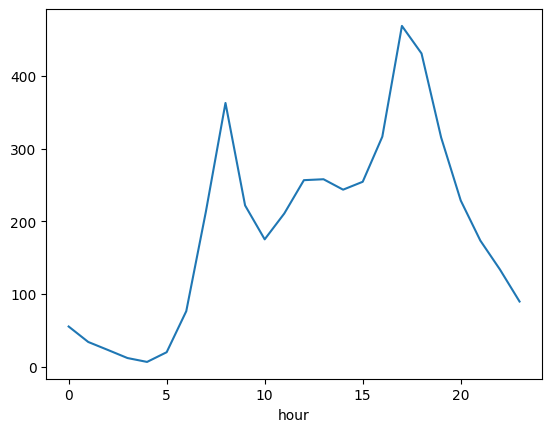

In [49]:
# Celda 2.1 - rentas promedio para cada valor de la variable "hour"
bikes.groupby('hour').total.mean().plot()

Como ya se habia mencionado en el punto anterior, el numero de alquileres a traves del dia sigue un patron que coincide con los horarios de entrada y salida del trabajo para muchas personas, alcanzando su punto máximo entre las 17 y 18 horas, y un segundo pico alrededor de las 8 horas

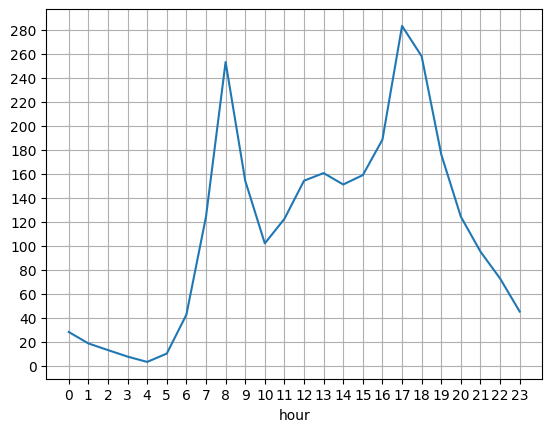

In [50]:
# Celda 2.2 - "season"=1 escriba su código y hallazgos 
# add grid to the plot
import matplotlib.pyplot as plt
bikes[bikes.season==1].groupby('hour').total.mean().plot()
plt.xticks(range(0,24))
plt.yticks(range(0,300,20))
plt.grid()

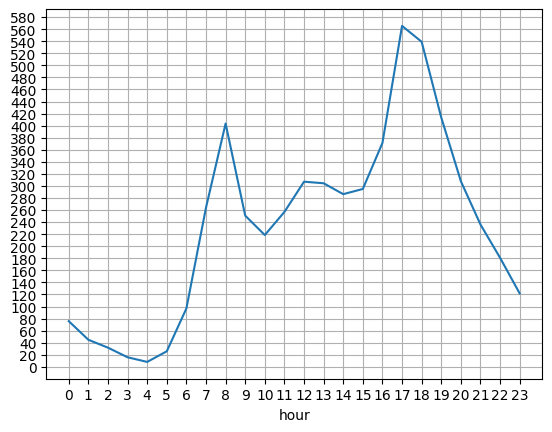

In [51]:
# Celda 2.3 - "season"=3 escriba su código y hallazgos
bikes[bikes.season==3].groupby('hour').total.mean().plot()
plt.xticks(range(0,24))
plt.yticks(range(0,600,20))
plt.grid()


Las diferencias entre las temporadas 1 y 3 se mantienen a lo largo del dia, con la temporada 3 mostrando un numero de alquileres significativamente mayor en cada hora del dia, hay ciertas diferencias, una de ellas es que el pico de la tarde en la temporada 3 es mas pronunciado que en la temporada 1, otra diferencia es que la caida de alquileres en la hora 19 no es tan pronunciada en la temporada 3 como en la temporada 1. Se puede resumir es que la diferencia en el comportamiento de los alquileres a lo largo del dia entre las temporadas 1 y 3 es que la temporada 3 tiene un numero de alquileres significativamente mayor en cada hora del dia, con un pico de la tarde mas pronunciado y una caida menos pronunciada en la hora 19

### Punto 3 - Regresión lineal
En la celda 3 ajuste un modelo de regresión lineal a un conjunto de train de datos, utilizando "total" como variable de respuesta y "season" y "hour" como las únicas variables predictoras, teniendo en cuenta que la variable "season" es categórica. Luego, imprima los coeficientes e interprételos. ¿Cuáles son las limitaciones de la regresión lineal en este caso?

In [52]:
# Celda 3
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import OneHotEncoder

X = bikes[['season', 'hour']].copy()
y = bikes['total'].copy()

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=1)

encoder = OneHotEncoder(sparse_output=False)
X_train_encoded = pd.concat([
    pd.DataFrame(encoder.fit_transform(X_train[['season']]), columns=encoder.get_feature_names_out()),
    pd.DataFrame(X_train['hour'].values, columns=['hour'])
], axis=1)
X_test_encoded = pd.concat([
    pd.DataFrame(encoder.transform(X_test[['season']]), columns=encoder.get_feature_names_out()),
    pd.DataFrame(X_test['hour'].values, columns=['hour'])
], axis=1)

lr = LinearRegression()
lr.fit(X_train_encoded, y_train)
y_train_pred = lr.predict(X_train_encoded)
y_test_pred = lr.predict(X_test_encoded)

def square_error(y_true, y_pred):
    return np.mean((y_true - y_pred) ** 2)

rmse_train = np.sqrt(square_error(y_train.values, y_train_pred))
rmse_test  = np.sqrt(square_error(y_test.values, y_test_pred))
print(f"R2 train: {lr.score(X_train_encoded, y_train):.2f} / test: {lr.score(X_test_encoded, y_test):.2f}")
print(f"RMSE train: {rmse_train:.2f} / test: {rmse_test:.2f}")
print(f"Coeficientes: {dict(zip(X_train_encoded.columns, lr.coef_.round(2)))}")


R2 train: 0.22 / test: 0.23
RMSE train: 158.80 / test: 161.63
Coeficientes: {'season_1': np.float64(-73.34), 'season_2': np.float64(20.56), 'season_3': np.float64(43.85), 'season_4': np.float64(8.93), 'hour': np.float64(10.59)}


El modelo predice pobremente el numero de bicicletas alquiladas con un error medio de ~160, posiblemente es debido a la no linealidad de la hora, como vimos previamente, si bien el numero de alquileres "aumenta a lo largo del dia" como generalidad, esto no es totalmente cierto, ya que como vemos, el numero de alquileres comienza a decrecer despues de la hora 17, y tambien hay un pico significativo en la hora 8. El modelo hace un trabajo pobre ajustandose a esto.

### Punto 4 - Árbol de decisión manual
En la celda 4 cree un árbol de decisiones para pronosticar la variable "total" iterando **manualmente** sobre las variables "hour" y  "season". El árbol debe tener al menos 6 nodos finales.

In [53]:
# Celda 4

class DecisionTreeRegressorScratch:
    def __init__(self, max_depth=None):
        self.max_depth = max_depth
        self.tree = None

    def fit(self, X, y):
        self.tree = self._build_tree(np.array(X), np.array(y), depth=0)

    def _build_tree(self, X, y, depth):
        if len(set(y)) == 1 or depth == self.max_depth:
            return np.mean(y)
        feature, threshold = self._best_split(X, y)
        if feature is None:
            return np.mean(y)
        left  = X[:, feature] <= threshold
        right = ~left
        return (feature, threshold,
                self._build_tree(X[left], y[left], depth + 1),
                self._build_tree(X[right], y[right], depth + 1))

    def _best_split(self, X, y):
        best_mse, best_feature, best_threshold = float('inf'), None, None
        for feature in range(X.shape[1]):
            for threshold in np.percentile(X[:, feature], range(0, 101, 5)):
                left = X[:, feature] <= threshold
                right = ~left
                if left.sum() == 0 or right.sum() == 0:
                    continue
                mse = (len(y[left])  * square_error(y[left], y[left].mean()) +
                       len(y[right]) * square_error(y[right], y[right].mean())) / len(y)
                if mse < best_mse:
                    best_mse, best_feature, best_threshold = mse, feature, threshold
        return best_feature, best_threshold

    def predict(self, X):
        return np.array([self._predict_single(x, self.tree) for x in np.array(X)])

    def _predict_single(self, x, tree):
        if not isinstance(tree, tuple):
            return tree
        feature, threshold, left, right = tree
        return self._predict_single(x, left if x[feature] <= threshold else right)


dt = DecisionTreeRegressorScratch(max_depth=4)
dt.fit(X_train_encoded, y_train)

y_train_pred_dt = dt.predict(X_train_encoded)
y_test_pred_dt  = dt.predict(X_test_encoded)

rmse_train = np.sqrt(square_error(y_train.values, y_train_pred_dt))
rmse_test  = np.sqrt(square_error(y_test.values, y_test_pred_dt))
print(f"RMSE train: {rmse_train:.2f} / test: {rmse_test:.2f}")


RMSE train: 124.91 / test: 126.16


In [54]:
dt.tree

(4,
 np.float64(7.0),
 (4,
  np.float64(6.0),
  (4,
   np.float64(5.0),
   (4,
    np.float64(1.0),
    np.float64(44.879120879120876),
    np.float64(15.422535211267606)),
   (0, np.float64(0.0), np.float64(86.29166666666667), np.float64(45.24))),
  (0,
   np.float64(0.0),
   (2,
    np.float64(0.0),
    np.float64(212.95652173913044),
    np.float64(271.390243902439)),
   np.float64(123.10810810810811))),
 (4,
  np.float64(20.0),
  (0,
   np.float64(0.0),
   (4,
    np.float64(15.0),
    np.float64(275.3007874015748),
    np.float64(395.9781512605042)),
   (4,
    np.float64(16.0),
    np.float64(162.6606397774687),
    np.float64(212.6327160493827))),
  (0,
   np.float64(0.0),
   (4,
    np.float64(21.0),
    np.float64(202.6891891891892),
    np.float64(126.44979079497908)),
   (4,
    np.float64(21.0),
    np.float64(93.94805194805195),
    np.float64(57.575949367088604)))))

In [55]:
y_test_pred_dt

array([275.3007874 ,  15.42253521, 395.97815126, ...,  15.42253521,
        15.42253521, 275.3007874 ])

### Punto 5 - Árbol de decisión con librería
En la celda 5 entrene un árbol de decisiones con la **librería sklearn**, usando las variables predictoras "season" y "hour" y calibre los parámetros que considere conveniente para obtener un mejor desempeño. Recuerde dividir los datos en conjuntos de entrenamiento y validación para esto. Comente el desempeño del modelo con alguna métrica de desempeño de modelos de regresión y compare desempeño con el modelo del punto 3.

Tenga en cuenta que, a diferencia del laboratorio, este problema es de regresión. Por lo tanto, para hacer cada split del árbol se debe utilizar algún criterio apropiado para problemas de regresión.

In [56]:
# Celda 5
from sklearn.tree import DecisionTreeRegressor

dt_sklearn = DecisionTreeRegressor(max_depth=10, random_state=1)
dt_sklearn.fit(X_train_encoded, y_train)

y_train_pred_sklearn = dt_sklearn.predict(X_train_encoded)
y_test_pred_sklearn  = dt_sklearn.predict(X_test_encoded)

rmse_train = np.sqrt(square_error(y_train.values, y_train_pred_sklearn))
rmse_test  = np.sqrt(square_error(y_test.values, y_test_pred_sklearn))
print(f"R2 train: {dt_sklearn.score(X_train_encoded, y_train):.2f} / test: {dt_sklearn.score(X_test_encoded, y_test):.2f}")
print(f"RMSE train: {rmse_train:.2f} / test: {rmse_test:.2f}")


R2 train: 0.61 / test: 0.61
RMSE train: 112.60 / test: 114.73


Si bien el rendimiento mejora con el cambio del modelo, el RMSE para el set de test pasa de 161 a 114, una mejora significativa, sin embargo aun hay mucha variabilidad en la variable del numero de bicicletas alquiladas que no es explicada. Esto se puede observar con el valor de R2 que es 0.61, el 39% de esta variable aun no ha podido ser predicha. 

El arbol de decision hace un mucho mejor trabajo modelando la variable horas, debido a su no linealidad. En cuanto a las temporadas al ser una variable categorica que fue codificada usando one hot encoder, no se ven ganancias tan significativas. Si esta variable se hubiera dejado tal y como se leyo del archivo, la regresion lineal tambien hubiera tenido un pobre desempeno sobre ella, y el arbol probablemente al igual que con la variable horas, haria un mucho mejor trabajo que la regresion


## Parte B - Métodos de ensamblajes
En esta parte del taller se usará el conjunto de datos de Popularidad de Noticias Online. El objetivo es predecir si la notica es popular o no, la popularidad está dada por la cantidad de reacciones en redes sociales. Para más detalles puede visitar el siguiente enlace: [datos](https://archive.ics.uci.edu/ml/datasets/online+news+popularity).

### Datos popularidad de noticias

In [57]:
# Lectura de la información de archivo .csv
df = pd.read_csv('https://raw.githubusercontent.com/davidzarruk/MIAD_ML_NLP_2023/main/datasets/mashable.csv', index_col=0)
df.head()

,url,timedelta,n_tokens_title,n_tokens_content,n_unique_tokens,n_non_stop_words,n_non_stop_unique_tokens,num_hrefs,num_self_hrefs,num_imgs,...,min_positive_polarity,max_positive_polarity,avg_negative_polarity,min_negative_polarity,max_negative_polarity,title_subjectivity,title_sentiment_polarity,abs_title_subjectivity,abs_title_sentiment_polarity,Popular
0,http://mashable.com/2014/12/10/cia-torture-rep...,28.0,9.0,188.0,0.732620,1.0,0.844262,5.0,1.0,1.0,...,0.200000,0.80,-0.487500,-0.60,-0.250000,0.9,0.8,0.4,0.8,1
1,http://mashable.com/2013/10/18/bitlock-kicksta...,447.0,7.0,297.0,0.653199,1.0,0.815789,9.0,4.0,1.0,...,0.160000,0.50,-0.135340,-0.40,-0.050000,0.1,-0.1,0.4,0.1,0
2,http://mashable.com/2013/07/24/google-glass-po...,533.0,11.0,181.0,0.660377,1.0,0.775701,4.0,3.0,1.0,...,0.136364,1.00,0.000000,0.00,0.000000,0.3,1.0,0.2,1.0,0
3,http://mashable.com/2013/11/21/these-are-the-m...,413.0,12.0,781.0,0.497409,1.0,0.677350,10.0,3.0,1.0,...,0.100000,1.00,-0.195701,-0.40,-0.071429,0.0,0.0,0.5,0.0,0
4,http://mashable.com/2014/02/11/parking-ticket-...,331.0,8.0,177.0,0.685714,1.0,0.830357,3.0,2.0,1.0,...,0.100000,0.55,-0.175000,-0.25,-0.100000,0.0,0.0,0.5,0.0,0


In [58]:
# Definición variable de interes y variables predictoras
X = df.drop(['url', 'Popular'], axis=1)
y = df['Popular']
y.mean()

np.float64(0.5)

In [59]:
# División de la muestra en set de entrenamiento y prueba
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=1)

### Punto 6 - Árbol de decisión y regresión logística
En la celda 6 construya un árbol de decisión y una regresión logística. Para el árbol calibre al menos un parámetro y evalúe el desempeño de cada modelo usando las métricas de Accuracy y F1-Score.

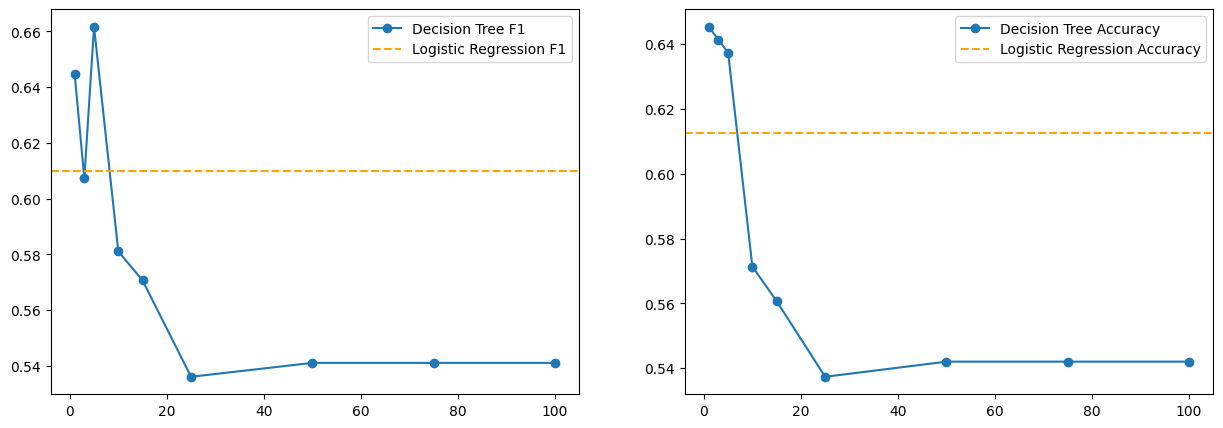

In [60]:
# Celda 6
from sklearn.metrics import accuracy_score, f1_score
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression

tree_depths = [1, 3, 5, 10, 15, 25, 50, 75, 100]
tree_f1_scores = []
tree_accuracies = []

for depth in tree_depths:
    tree = DecisionTreeClassifier(max_depth=depth, random_state=1)
    tree.fit(X_train, y_train)
    y_pred = tree.predict(X_test)
    tree_f1_scores.append(f1_score(y_test, y_pred))
    tree_accuracies.append(accuracy_score(y_test, y_pred))
    
logreg = LogisticRegression(random_state=1)
logreg.fit(X_train, y_train)
y_pred_logreg = logreg.predict(X_test)
logreg_f1 = f1_score(y_test, y_pred_logreg)
logreg_acc = accuracy_score(y_test, y_pred_logreg)

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

axes[0].plot(tree_depths, tree_f1_scores, marker='o', label='Decision Tree F1')
axes[0].axhline(y=logreg_f1, label='Logistic Regression F1', linestyle='--', color='orange')
axes[0].legend()

axes[1].plot(tree_depths, tree_accuracies, marker='o', label='Decision Tree Accuracy')
axes[1].axhline(y=logreg_acc, label='Logistic Regression Accuracy', linestyle='--', color='orange')
axes[1].legend()
plt.show()


### Punto 7 - Votación Mayoritaria
En la celda 7 elabore un esamble con la metodología de **Votación mayoritaria** compuesto por 300 muestras bagged donde:

-las primeras 100 muestras de bootstrap vienen de árboles de decisión donde max_depth tome un valor de su elección\
-las segundas 100 muestras de bootstrap vienen de árboles de decisión donde min_samples_leaf tome un valor de su elección\
-las últimas 100 muestras de bootstrap vienen de regresiones logísticas

Evalúe cada uno de los tres modelos de manera independiente utilizando las métricas de Accuracy y F1-Score, luego evalúe el ensamble de modelos y compare los resultados. 

Nota: 

Para este ensamble de 300 modelos, deben hacer votación mayoritaria. Esto lo pueden hacer de distintas maneras. La más "fácil" es haciendo la votación "manualmente", como se hace a partir del minuto 5:45 del video de Ejemplo práctico de emsablajes en Coursera. Digo que es la más fácil porque si hacen la votación mayoritaria sobre las 300 predicciones van a obtener lo que se espera.

Otra opción es: para cada uno de los 3 tipos de modelos, entrenar un ensamble de 100 modelos cada uno. Predecir para cada uno de esos tres ensambles y luego predecir como un ensamble de los 3 ensambles. La cuestión es que la votación mayoritaria al usar los 3 ensambles no necesariamente va a generar el mismo resultado que si hacen la votación mayoritaria directamente sobre los 300 modelos. Entonces, para los que quieran hacer esto, deben hacer ese último cálculo con cuidado.

Para los que quieran hacerlo como ensamble de ensambles, digo que se debe hacer el ensamble final con cuidado por lo siguiente. Supongamos que:

* para los 100 árboles del primer tipo, la votación mayoritaria es: 55% de los modelos predicen que la clase de una observación es "1"
* para los 100 árboles del segundo tipo, la votación mayoritaria es: 55% de los modelos predicen que la clase de una observación es "1"
* para las 100 regresiones logísticas, la votación mayoritaria es: 10% de los modelos predicen que la clase de una observación es "1"

Si se hace la votación mayoritaria de los 300 modelos, la predicción de esa observación debería ser: (100*55%+100*55%+100*10%)/300 = 40% de los modelos votan porque la predicción debería ser "1". Es decir, la predicción del ensamble es "0" (dado que menos del 50% de modelos predijo un 1).

Sin embargo, si miramos cada ensamble por separado, el primer ensamble predice "1", el segundo ensamble predice "1" y el último ensamble predice "0". Si hago votación mayoritaria sobre esto, la predicción va a ser "1", lo cual es distinto a si se hace la votación mayoritaria sobre los 300 modelos.

In [61]:
# Celda 7

def bootstrap_sample(X, y):
    n_samples = len(X)
    indices = np.random.choice(n_samples, size=n_samples, replace=True)
    return X.iloc[indices], y.iloc[indices]

class TreeEnsemble:
    def __init__(self, n_trees=100, max_depth=None, min_sample_leaf=1):
        self.n_trees = n_trees
        self.max_depth = max_depth
        self.min_sample_leaf = min_sample_leaf
        self.models = []
        self.accuracies = []
        
    def fit(self, X, y):
        for _ in range(self.n_trees):
            X_sample, y_sample = bootstrap_sample(X, y)
            tree = DecisionTreeClassifier(max_depth=self.max_depth, min_samples_leaf=self.min_sample_leaf, random_state=1)
            tree.fit(X_sample, y_sample)
            self.models.append(tree)
            self.accuracies.append(tree.score(X_sample, y_sample))

    def predict(self, X):
        tree_preds = np.array([tree.predict(X) for tree in self.models])
        return np.round(tree_preds.mean(axis=0)).astype(int)

ensemble_tree_1 = TreeEnsemble(n_trees=100, max_depth=10)
ensemble_tree_2 = TreeEnsemble(n_trees=100, min_sample_leaf=10)

ensemble_tree_1.fit(X_train, y_train)
ensemble_tree_2.fit(X_train, y_train)

y_pred_ensemble_1 = ensemble_tree_1.predict(X_test)
y_pred_ensemble_2 = ensemble_tree_2.predict(X_test)

print(f"F1 Ensemble Tree 1: {f1_score(y_test, y_pred_ensemble_1):.2f}, Accuracy: {accuracy_score(y_test, y_pred_ensemble_1):.2f}")
print(f"F1 Ensemble Tree 2: {f1_score(y_test, y_pred_ensemble_2):.2f}, Accuracy: {accuracy_score(y_test, y_pred_ensemble_2):.2f}")


class LogisticEnsemble:
    def __init__(self, n_models=100):
        self.n_models = n_models
        self.models = []
        self.accuracies = []
        
    def fit(self, X, y):
        for _ in range(self.n_models):
            X_sample, y_sample = bootstrap_sample(X, y)
            model = LogisticRegression(random_state=1)
            model.fit(X_sample, y_sample)
            self.models.append(model)
            self.accuracies.append(model.score(X_sample, y_sample))

    def predict(self, X):
        model_preds = np.array([model.predict(X) for model in self.models])
        return np.round(model_preds.mean(axis=0)).astype(int)
    
ensemble_logreg = LogisticEnsemble(n_models=100)
ensemble_logreg.fit(X_train, y_train)
y_pred_ensemble_logreg = ensemble_logreg.predict(X_test)
print(f"F1 Ensemble Logistic Regression: {f1_score(y_test, y_pred_ensemble_logreg):.2f}, Accuracy: {accuracy_score(y_test, y_pred_ensemble_logreg):.2f}")

F1 Ensemble Tree 1: 0.65, Accuracy: 0.65
F1 Ensemble Tree 2: 0.64, Accuracy: 0.65
F1 Ensemble Logistic Regression: 0.61, Accuracy: 0.62


In [62]:
class MetaEnsemble:
    def __init__(self, ensembles):
        self.ensembles = ensembles
        
    def predict(self, X, vote_weight_type="uniform"):
        models = []
        accuracies = []
        for ensemble in self.ensembles:
            models.extend(ensemble.models)
            accuracies.extend(ensemble.accuracies)

        ensemble_preds = np.array([model.predict(X) for model in models])
        if vote_weight_type == "accuracy":
            weights = np.array(accuracies) / np.sum(accuracies)
            weighted_preds = np.average(ensemble_preds, axis=0, weights=weights)
            return np.round(weighted_preds).astype(int)
        else:
            return np.round(ensemble_preds.mean(axis=0)).astype(int)
    
meta_ensemble = MetaEnsemble(ensembles=[ensemble_tree_1, ensemble_tree_2, ensemble_logreg])
y_pred_meta = meta_ensemble.predict(X_test)
print(f"F1 Meta Ensemble: {f1_score(y_test, y_pred_meta):.2f}, Accuracy: {accuracy_score(y_test, y_pred_meta):.2f}")

F1 Meta Ensemble: 0.62, Accuracy: 0.62


### Punto 8 - Votación Ponderada
En la celda 8 elabore un ensamble con la metodología de **Votación ponderada** compuesto por 300 muestras bagged para los mismos tres escenarios del punto 7. Evalúe los modelos utilizando las métricas de Accuracy y F1-Score

In [63]:
# Celda 8

y_pred_meta_weighted = meta_ensemble.predict(X_test, vote_weight_type="accuracy")
print(f"F1 Meta Ensemble Ponderado: {f1_score(y_test, y_pred_meta_weighted):.2f}, Accuracy: {accuracy_score(y_test, y_pred_meta_weighted):.2f}")


F1 Meta Ensemble Ponderado: 0.63, Accuracy: 0.63


### Punto 9 - Comparación y análisis de resultados
En la celda 9 comente sobre los resultados obtenidos con las metodologías usadas en los puntos 7 y 8, compare los resultados y enuncie posibles ventajas o desventajas de cada una de ellas.

In [64]:
# Celda 9

Las dos metodologias usadas no muestran diferencias significativas en terminos de F1 y Accuracy. Muy seguramente esto es causado por el hecho de que los modelos tienen desempenos muy similares, como fue observado en el punto 6, lo sorprendente es como el desempeno del arbol de decision alcanza maximos a menor numero de ramas, lo que da a creer que tiene dificultad aprendiendo de la informacion a partir del primer nodo, este primer nodo mejora la clasificacion ya que el balance de clases es de 1:1 (0.5 es la media de la var y) y un arbol con un nodo de profundidad tiene un accuracy ~0.64.

Este fenomeno es lo que permite explicar el porque no se observa una mejora significativa usando los ensembles, ya que estos tienen un mayor impacto positivo sobre modelos con alta variabilidad que tienden al sobreajuste, nuestros modelos no tienden al sobreajuste, ya que no estan aprendiendo informacion nueva conforme los arboles crecen, y en el caso de la regresion logistica debido a que es un modelo poco flexible y con poca tendencia al sobreajuste.

La ventaja de la votacion mayoritaria es su simplicidad y menor uso de recursos computacionales, su desventaja en comparacion con la votacion ponderada es que es menos flexible, esto implica que tendra menos tendencia al sobreajuste, pero tendra menor poder predictivo.